#Sandesh Suman(M25CSA034)
# CSL7110 Assignment 3: Recommender Systems
## Content-Based and Collaborative Filtering on MovieLens Dataset


**Dataset:** MovieLens (ml-latest-small)  


## Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from scipy.sparse.linalg import svds
from scipy.stats import pearsonr



In [2]:
DATA_PATH = 'ml-latest-small/'

# Load core files
movies  = pd.read_csv(DATA_PATH + 'movies.csv')
ratings = pd.read_csv(DATA_PATH + 'ratings.csv')

print(f"Movies  : {movies.shape}")
print(f"Ratings : {ratings.shape}")
movies.head()

Movies  : (9742, 3)
Ratings : (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
#Basic Data Exploration
print("Rating distribution:")
print(ratings['rating'].describe())

print(f"\nUnique users  : {ratings['userId'].nunique()}")
print(f"Unique movies : {ratings['movieId'].nunique()}")
print(f"Unique genres : {movies['genres'].str.split('|').explode().nunique()}")

# Clean up: drop movies with no listed genre
movies = movies[movies['genres'] != '(no genres listed)'].reset_index(drop=True)
ratings = ratings[ratings['movieId'].isin(movies['movieId'])].reset_index(drop=True)

print(f"\nAfter cleaning — Movies: {len(movies)}, Ratings: {len(ratings)}")

Rating distribution:
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Unique users  : 610
Unique movies : 9724
Unique genres : 20

After cleaning — Movies: 9708, Ratings: 100789


---
# PART 1 — Content-Based Filtering

## Task 1: TF-IDF Based Recommendation

In [4]:
#  Step 1: Extract genre descriptions
# Replace '|' with space so TF-IDF treats each genre as a separate token
movies['genre_str'] = movies['genres'].str.replace('|', ' ', regex=False)

print("Sample genre strings:")
print(movies[['title', 'genre_str']].head(10).to_string(index=False))

Sample genre strings:
                             title                                   genre_str
                  Toy Story (1995) Adventure Animation Children Comedy Fantasy
                    Jumanji (1995)                  Adventure Children Fantasy
           Grumpier Old Men (1995)                              Comedy Romance
          Waiting to Exhale (1995)                        Comedy Drama Romance
Father of the Bride Part II (1995)                                      Comedy
                       Heat (1995)                       Action Crime Thriller
                    Sabrina (1995)                              Comedy Romance
               Tom and Huck (1995)                          Adventure Children
               Sudden Death (1995)                                      Action
                  GoldenEye (1995)                   Action Adventure Thriller


In [5]:
# Step 2: Compute TF-IDF vectors
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genre_str'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
# rows = movies, cols = unique genre tokens

TF-IDF matrix shape: (9708, 21)


In [6]:
# Step 3: Compute cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Cosine similarity matrix shape: {cosine_sim.shape}")

# Map movie title → index for quick lookup
title_to_idx = pd.Series(movies.index, index=movies['title']).drop_duplicates()

Cosine similarity matrix shape: (9708, 9708)


In [7]:
#  Step 4: Recommendation function
def get_content_recommendations(title, top_n=5):
    """
    Returns the top-N most similar movies to a given title
    based on TF-IDF genre vectors and cosine similarity.
    """
    if title not in title_to_idx:
        # Fuzzy match: find closest title
        matches = movies[movies['title'].str.contains(title, case=False, na=False)]
        if matches.empty:
            print(f"Movie '{title}' not found.")
            return None
        title = matches.iloc[0]['title']
        print(f"Using closest match: '{title}'")

    idx = title_to_idx[title]
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity descending, skip the movie itself (score=1.0)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    movie_indices = [i[0] for i in sim_scores]
    scores        = [round(i[1], 4) for i in sim_scores]

    result = movies.iloc[movie_indices][['title', 'genres']].copy()
    result['cosine_similarity'] = scores
    return result.reset_index(drop=True)

In [8]:
# Step 5: Test with sample queries
test_movies = ['Toy Story (1995)', 'Jumanji (1995)', 'Heat (1995)']

for m in test_movies:
    print(f"\n{'='*60}")
    print(f"Top-5 recommendations for: {m}")
    print('='*60)
    recs = get_content_recommendations(m, top_n=5)
    if recs is not None:
        print(recs.to_string(index=False))


Top-5 recommendations for: Toy Story (1995)
                                         title                                      genres  cosine_similarity
                                   Antz (1998) Adventure|Animation|Children|Comedy|Fantasy                1.0
                            Toy Story 2 (1999) Adventure|Animation|Children|Comedy|Fantasy                1.0
Adventures of Rocky and Bullwinkle, The (2000) Adventure|Animation|Children|Comedy|Fantasy                1.0
              Emperor's New Groove, The (2000) Adventure|Animation|Children|Comedy|Fantasy                1.0
                         Monsters, Inc. (2001) Adventure|Animation|Children|Comedy|Fantasy                1.0

Top-5 recommendations for: Jumanji (1995)
                                    title                     genres  cosine_similarity
       Indian in the Cupboard, The (1995) Adventure|Children|Fantasy                1.0
        NeverEnding Story III, The (1994) Adventure|Children|Fantasy        

## Task 2: User-Profile-Based Content Recommender

In [9]:
# Build user profiles as weighted averages of TF-IDF vectors
# movieId → row index in tfidf_matrix
movieid_to_idx = pd.Series(movies.index, index=movies['movieId']).drop_duplicates()

# Dense TF-IDF matrix for vectorized operations
tfidf_dense = tfidf_matrix.toarray()

def build_user_profile(user_id):
    """
    Constructs a user profile vector as the rating-weighted average
    of TF-IDF genre vectors of movies the user has rated.
    P_u = sum(r_{u,m} * f_m) / sum(r_{u,m})
    """
    user_ratings = ratings[ratings['userId'] == user_id]
    # Keep only movies present in our cleaned movies dataframe
    user_ratings = user_ratings[user_ratings['movieId'].isin(movieid_to_idx.index)]

    if user_ratings.empty:
        return None

    # Gather TF-IDF vectors and corresponding ratings
    indices = movieid_to_idx[user_ratings['movieId']].values
    rating_weights = user_ratings['rating'].values.reshape(-1, 1)

    weighted_vecs = tfidf_dense[indices] * rating_weights   # shape: (n_rated, n_genres)
    profile = weighted_vecs.sum(axis=0) / rating_weights.sum()  # normalize
    return profile

# Test: build profile for user 1
profile_u1 = build_user_profile(1)
print(f"User 1 profile shape : {profile_u1.shape}")
print(f"Profile norm         : {np.linalg.norm(profile_u1):.4f}")

User 1 profile shape : (21,)
Profile norm         : 0.4590


In [10]:
# Compute user-movie similarity and return top-N recommendations
def user_profile_recommendations(user_id, top_n=10, exclude_rated=True):
    """
    Recommends top-N movies for a user based on cosine similarity
    between their profile vector and all movie TF-IDF vectors.
    """
    profile = build_user_profile(user_id)
    if profile is None:
        print(f"No ratings found for user {user_id}")
        return None

    # Cosine similarity: (1, n_genres) x (n_movies, n_genres)^T
    sim_scores = cosine_similarity(profile.reshape(1, -1), tfidf_dense)[0]


    if exclude_rated:
        rated_ids = ratings[ratings['userId'] == user_id]['movieId'].values
        rated_indices = movieid_to_idx[movieid_to_idx.index.isin(rated_ids)].values
        sim_scores[rated_indices] = -1  # mask out rated movies

    top_indices = np.argsort(sim_scores)[::-1][:top_n]
    result = movies.iloc[top_indices][['title', 'genres']].copy()
    result['similarity'] = sim_scores[top_indices].round(4)
    return result.reset_index(drop=True)

print("Top-10 recommendations for User 1:")
print(user_profile_recommendations(1).to_string(index=False))

Top-10 recommendations for User 1:
                                        title                                          genres  similarity
        Dragonheart 2: A New Beginning (2000)  Action|Adventure|Comedy|Drama|Fantasy|Thriller      0.7909
                    Hunting Party, The (2007)          Action|Adventure|Comedy|Drama|Thriller      0.7736
               The Great Train Robbery (1978)             Action|Adventure|Comedy|Crime|Drama      0.7730
                             Flashback (1990)             Action|Adventure|Comedy|Crime|Drama      0.7730
       Charlie's Angels: Full Throttle (2003)          Action|Adventure|Comedy|Crime|Thriller      0.7605
                      After the Sunset (2004)          Action|Adventure|Comedy|Crime|Thriller      0.7605
                               Machete (2010)          Action|Adventure|Comedy|Crime|Thriller      0.7605
Diamond Arm, The (Brilliantovaya ruka) (1968)          Action|Adventure|Comedy|Crime|Thriller      0.7605
           

In [11]:
#  Evaluate Personalization: Precision@K and Recall@K
def evaluate_user_profile(user_id, K=10, threshold=4.0):
    """
    Evaluates recommendations using Precision@K and Recall@K.
    Ground truth = movies the user rated >= threshold.
    """
    user_ratings = ratings[ratings['userId'] == user_id]
    relevant = set(user_ratings[user_ratings['rating'] >= threshold]['movieId'].values)

    if not relevant:
        return None

    recs = user_profile_recommendations(user_id, top_n=K, exclude_rated=False)
    if recs is None:
        return None

    rec_ids = set(movies[movies['title'].isin(recs['title'])]['movieId'].values)
    hits = len(rec_ids & relevant)

    precision = hits / K
    recall    = hits / len(relevant) if relevant else 0
    return {'precision@K': round(precision, 4), 'recall@K': round(recall, 4), 'K': K}

# Evaluate on first 10 users
eval_results = []
for uid in ratings['userId'].unique()[:10]:
    res = evaluate_user_profile(uid, K=10)
    if res:
        res['userId'] = uid
        eval_results.append(res)

eval_df = pd.DataFrame(eval_results)
print("\nContent-Based (User Profile) Evaluation:")
print(eval_df.to_string(index=False))
print(f"\nMean Precision@10 : {eval_df['precision@K'].mean():.4f}")
print(f"Mean Recall@10    : {eval_df['recall@K'].mean():.4f}")


Content-Based (User Profile) Evaluation:
 precision@K  recall@K  K  userId
         0.0    0.0000 10       1
         0.0    0.0000 10       2
         0.1    0.0625 10       3
         0.0    0.0000 10       4
         0.0    0.0000 10       5
         0.0    0.0000 10       6
         0.0    0.0000 10       7
         0.1    0.0455 10       8
         0.1    0.0455 10       9
         0.0    0.0000 10      10

Mean Precision@10 : 0.0300
Mean Recall@10    : 0.0153


---
# PART 2 — Collaborative Filtering

In [12]:
# Build the user-movie rating matrix
active_users = ratings['userId'].value_counts()
active_users = active_users[active_users >= 50].index

ratings_sub = ratings[ratings['userId'].isin(active_users)]
print(f"Active users    : {len(active_users)}")
print(f"Ratings in sub  : {len(ratings_sub)}")

# Pivot: rows=users, cols=movies, values=ratings (NaN for unseen)
user_movie_matrix = ratings_sub.pivot_table(
    index='userId', columns='movieId', values='rating'
)

print(f"User-Movie matrix shape: {user_movie_matrix.shape}")
print(f"Sparsity: {100 * user_movie_matrix.isna().sum().sum() / user_movie_matrix.size:.1f}%")

Active users    : 385
Ratings in sub  : 93767
User-Movie matrix shape: (385, 9600)
Sparsity: 97.5%


## Task 3: User-Based Collaborative Filtering

In [13]:
# Compute user-user similarity (Pearson correlation)\
# Fill NaN with 0 for similarity computation
matrix_filled = user_movie_matrix.fillna(0).values   # numpy array
user_ids      = user_movie_matrix.index.tolist()
movie_ids_cf  = user_movie_matrix.columns.tolist()

# Pearson correlation between users (row-wise)
# Using numpy corrcoef for efficiency
user_similarity = np.corrcoef(matrix_filled)  # shape: (n_users, n_users)
user_sim_df = pd.DataFrame(user_similarity, index=user_ids, columns=user_ids)

print(f"User similarity matrix shape: {user_sim_df.shape}")
print("\nSample (top-left 5x5):")
print(user_sim_df.iloc[:5, :5].round(3))

User similarity matrix shape: (385, 385)

Sample (top-left 5x5):
       1      4      6      7      10
1   1.000  0.177  0.104  0.144 -0.001
4   0.177  1.000  0.065  0.100  0.015
6   0.104  0.065  1.000  0.057  0.000
7   0.144  0.100  0.057  1.000  0.120
10 -0.001  0.015  0.000  0.120  1.000


In [14]:
# Predict rating for a user-movie pair using K nearest neighborS
def predict_rating_user_cf(user_id, movie_id, K=20):
    """
    Predicts the rating for (user_id, movie_id) using weighted
    average of K most similar users who have rated that movie.
    """
    if movie_id not in user_movie_matrix.columns:
        return user_movie_matrix.loc[user_id].mean()

    # Similarity of target user with all others
    sim_scores = user_sim_df[user_id].drop(user_id)

    # Only consider users who have rated this movie
    rated_mask = user_movie_matrix[movie_id].notna()
    rated_mask = rated_mask[rated_mask].index
    sim_scores = sim_scores[sim_scores.index.isin(rated_mask)]

    if sim_scores.empty:
        return user_movie_matrix.loc[user_id].mean()

    # Top-K neighbours
    top_k = sim_scores.nlargest(K)
    neighbour_ratings = user_movie_matrix.loc[top_k.index, movie_id]

    numerator   = (top_k * neighbour_ratings).sum()
    denominator = top_k.abs().sum()

    if denominator == 0:
        return user_movie_matrix.loc[user_id].mean()

    pred = numerator / denominator
    return np.clip(pred, 0.5, 5.0)


def user_based_cf_recommend(user_id, top_n=10, K=20):
    """
    Generates top-N movie recommendations for a user using User-Based CF.
    """
    if user_id not in user_movie_matrix.index:
        print(f"User {user_id} not in active user set.")
        return None

    # Movies the user has NOT rated
    rated    = user_movie_matrix.loc[user_id].dropna().index
    unrated  = [m for m in movie_ids_cf if m not in rated]

    preds = {mid: predict_rating_user_cf(user_id, mid, K) for mid in unrated}
    top_preds = sorted(preds.items(), key=lambda x: x[1], reverse=True)[:top_n]

    result_ids   = [p[0] for p in top_preds]
    result_preds = [round(p[1], 3) for p in top_preds]

    result = movies[movies['movieId'].isin(result_ids)][['movieId','title','genres']].copy()
    pred_map = dict(zip(result_ids, result_preds))
    result['predicted_rating'] = result['movieId'].map(pred_map)
    return result.sort_values('predicted_rating', ascending=False).reset_index(drop=True)


# Test
sample_user = user_ids[0]
print(f"Top-10 User-CF recommendations for user {sample_user}:")
print(user_based_cf_recommend(sample_user).to_string(index=False))

Top-10 User-CF recommendations for user 1:
 movieId                                             title                         genres  predicted_rating
      53                                   Lamerica (1994)                Adventure|Drama               5.0
      99              Heidi Fleiss: Hollywood Madam (1995)                    Documentary               5.0
     148                  Awfully Big Adventure, An (1995)                          Drama               5.0
     389                        Colonel Chabert, Le (1994)              Drama|Romance|War               5.0
     467                            Live Nude Girls (1995)                         Comedy               5.0
     495 In the Realm of the Senses (Ai no corrida) (1976)                          Drama               5.0
     496                       What Happened Was... (1994)  Comedy|Drama|Romance|Thriller               5.0
     633                            Denise Calls Up (1995)                         Comedy    

In [15]:
# Faster version: sample rated movies instead of using all
def evaluate_user_cf(n_users=20, K_rec=10, K_neighbours=20, threshold=4.0):
    rmse_list, prec_list, rec_list = [], [], []

    for uid in user_ids[:n_users]:
        user_rated = user_movie_matrix.loc[uid].dropna()
        if len(user_rated) < 5:
            continue

        # Sample max 30 movies for RMSE (instead of all rated movies)
        sample = user_rated.sample(min(30, len(user_rated)), random_state=42)

        actuals, preds = [], []
        for mid, actual in sample.items():
            pred = predict_rating_user_cf(uid, mid, K_neighbours)
            actuals.append(actual)
            preds.append(pred)
        rmse_list.append(np.sqrt(mean_squared_error(actuals, preds)))

        relevant = set(user_rated[user_rated >= threshold].index)
        recs = user_based_cf_recommend(uid, top_n=K_rec, K=K_neighbours)
        if recs is None:
            continue
        rec_set = set(recs['movieId'].values)
        hits = len(rec_set & relevant)
        prec_list.append(hits / K_rec)
        rec_list.append(hits / len(relevant) if relevant else 0)

    return {
        'RMSE'        : round(np.mean(rmse_list), 4),
        'Precision@K' : round(np.mean(prec_list), 4),
        'Recall@K'    : round(np.mean(rec_list),  4)
    }

## Task 4: Item-Based Collaborative Filtering

In [16]:
#  Compute item-item similarity (cosine)
# Transpose so rows = movies, cols = users; fill NaN with 0
item_matrix = user_movie_matrix.fillna(0).T.values   # shape: (n_movies, n_users)

item_similarity = cosine_similarity(item_matrix)      # shape: (n_movies, n_movies)
item_sim_df = pd.DataFrame(
    item_similarity,
    index   = movie_ids_cf,
    columns = movie_ids_cf
)
print(f"Item similarity matrix shape: {item_sim_df.shape}")

Item similarity matrix shape: (9600, 9600)


In [17]:
#  Predict rating using item-item similarity
def predict_rating_item_cf(user_id, movie_id, K=20):
    """
    Predicts rating for (user_id, movie_id) using weighted average
    of similar items that the user has already rated.
    Higher similarity = higher weight.
    """
    if movie_id not in item_sim_df.columns:
        return 3.0

    # Items the user has rated
    user_rated = user_movie_matrix.loc[user_id].dropna()
    rated_ids  = user_rated.index.tolist()

    # Similarities between target movie and rated movies
    sim_scores = item_sim_df.loc[movie_id, rated_ids].dropna()
    if sim_scores.empty:
        return user_rated.mean()

    top_k = sim_scores.nlargest(K)
    numerator   = (top_k * user_rated[top_k.index]).sum()
    denominator = top_k.abs().sum()

    if denominator == 0:
        return user_rated.mean()

    return np.clip(numerator / denominator, 0.5, 5.0)


def item_based_cf_recommend(user_id, top_n=10, K=20):
    """
    Generates top-N recommendations for a user using Item-Based CF.
    """
    if user_id not in user_movie_matrix.index:
        return None

    rated   = user_movie_matrix.loc[user_id].dropna().index
    unrated = [m for m in movie_ids_cf if m not in rated]

    preds    = {mid: predict_rating_item_cf(user_id, mid, K) for mid in unrated}
    top_preds = sorted(preds.items(), key=lambda x: x[1], reverse=True)[:top_n]

    result_ids   = [p[0] for p in top_preds]
    result_preds = [round(p[1], 3) for p in top_preds]

    result = movies[movies['movieId'].isin(result_ids)][['movieId','title','genres']].copy()
    pred_map = dict(zip(result_ids, result_preds))
    result['predicted_rating'] = result['movieId'].map(pred_map)
    return result.sort_values('predicted_rating', ascending=False).reset_index(drop=True)


print(f"Top-10 Item-CF recommendations for user {sample_user}:")
print(item_based_cf_recommend(sample_user).to_string(index=False))

Top-10 Item-CF recommendations for user 1:
 movieId                                                   title                                          genres  predicted_rating
  103210    Fullmetal Alchemist: The Sacred Star of Milos (2011)                      Action|Adventure|Animation               5.0
  127212                   The Stanford Prison Experiment (2015)                                  Drama|Thriller               5.0
  148978                         Blue Exorcist: The Movie (2012)                Animation|Fantasy|Horror|Mystery               5.0
  157369                                          Bakuman (2015)                                    Comedy|Drama               5.0
  158035 Gintama: The Final Chapter - Be Forever Yorozuya (2013)                         Action|Animation|Comedy               5.0
  161594                    Kingsglaive: Final Fantasy XV (2016) Action|Adventure|Animation|Drama|Fantasy|Sci-Fi               5.0
  162968                  Kizumonogatari

In [18]:
#  Compare User-CF vs Item-CF
from sklearn.metrics import mean_squared_error
def evaluate_item_cf(n_users=15, K_rec=10, K_neighbours=20, threshold=4.0):
    rmse_list, prec_list, rec_list = [], [], []
    for uid in user_ids[:n_users]:
        user_rated = user_movie_matrix.loc[uid].dropna()
        if len(user_rated) < 5:
            continue
        actuals, preds = [], []
        for mid, actual in user_rated.items():
            pred = predict_rating_item_cf(uid, mid, K_neighbours)
            actuals.append(actual)
            preds.append(pred)
        rmse_list.append(np.sqrt(mean_squared_error(actuals, preds)))

        relevant = set(user_rated[user_rated >= threshold].index)
        recs = item_based_cf_recommend(uid, top_n=K_rec, K=K_neighbours)
        if recs is None:
            continue
        rec_set = set(recs['movieId'].values)
        hits = len(rec_set & relevant)
        prec_list.append(hits / K_rec)
        rec_list.append(hits / len(relevant) if relevant else 0)

    return {
        'RMSE'        : round(np.mean(rmse_list), 4),
        'Precision@K' : round(np.mean(prec_list), 4),
        'Recall@K'    : round(np.mean(rec_list),  4)
    }

ucf = evaluate_user_cf(n_users=15, K_neighbours=20)
icf = evaluate_item_cf(n_users=15, K_neighbours=20)

compare_df = pd.DataFrame([ucf, icf], index=['User-Based CF', 'Item-Based CF'])
print("\n── CF Comparison ─")
print(compare_df)


── CF Comparison ─
                 RMSE  Precision@K  Recall@K
User-Based CF  1.0840          0.0       0.0
Item-Based CF  0.8074          0.0       0.0


In [ ]:
# Q: Is Item-Based CF faster / more memory-efficient in the real world?
print("""
Answer: Yes, Item-Based CF is generally more scalable in practice.

Reasons:
1. STABILITY: The number of items (movies) grows much slower than the number of
   users on large platforms. Once the item-item similarity matrix is computed,
   it can be cached and reused — it doesn't change every time a new user signs up.

2. COMPUTATION: For a platform with M items and N users (N >> M), the item-item
   matrix is M×M (smaller) while user-user is N×N (enormous). Amazon, for example,
   popularised item-based CF for exactly this reason.

3. MEMORY: Pre-computing and storing item similarity is feasible; storing all
   pairwise user similarities for millions of users is not.

4. LATENCY: At query time, item-CF only needs to look up pre-computed item
   similarities, making real-time recommendations faster.
""")


Answer: Yes, Item-Based CF is generally more scalable in practice.

Reasons:
1. STABILITY: The number of items (movies) grows much slower than the number of
   users on large platforms. Once the item-item similarity matrix is computed,
   it can be cached and reused — it doesn't change every time a new user signs up.

2. COMPUTATION: For a platform with M items and N users (N >> M), the item-item
   matrix is M×M (smaller) while user-user is N×N (enormous). Amazon, for example,
   popularised item-based CF for exactly this reason.

3. MEMORY: Pre-computing and storing item similarity is feasible; storing all
   pairwise user similarities for millions of users is not.

4. LATENCY: At query time, item-CF only needs to look up pre-computed item
   similarities, making real-time recommendations faster.



---
# PART 3 — Matrix Factorization

## Task 5: Implementing SVD for Recommendations

In [19]:
# Step 1: Prepare the user-item matrix for SVD
# Fill missing ratings with each user's mean rating (reduces bias)
matrix_for_svd = user_movie_matrix.copy()
user_means = matrix_for_svd.mean(axis=1)  # mean rating per user

# Mean-centre the matrix (subtract user mean)
matrix_centered = matrix_for_svd.subtract(user_means, axis=0).fillna(0).values

print(f"Matrix for SVD shape : {matrix_centered.shape}")
print(f"Non-zero entries     : {np.count_nonzero(matrix_centered)}")

Matrix for SVD shape : (385, 9600)
Non-zero entries     : 93640


In [20]:
# Step 2: Apply Truncated SVD
# k = number of latent factors (tune this)
k = 50
U, sigma, Vt = svds(matrix_centered, k=k)

# Convert sigma to diagonal matrix
sigma_diag = np.diag(sigma)

print(f"U shape     : {U.shape}")
print(f"Sigma shape : {sigma_diag.shape}")
print(f"Vt shape    : {Vt.shape}")

U shape     : (385, 50)
Sigma shape : (50, 50)
Vt shape    : (50, 9600)


In [21]:
# Step 3: Reconstruct rating matrix and predict
# R_hat = U * Sigma_k * Vt  (mean-centred reconstruction)
R_hat_centered = np.dot(np.dot(U, sigma_diag), Vt)

# Add back user means to de-normalise
R_hat = R_hat_centered + user_means.values.reshape(-1, 1)

# Clip to valid rating range [0.5, 5.0]
R_hat = np.clip(R_hat, 0.5, 5.0)

# Wrap in DataFrame for easy indexing
R_hat_df = pd.DataFrame(R_hat, index=user_movie_matrix.index, columns=user_movie_matrix.columns)

print("Reconstructed rating matrix (first 5x5):")
print(R_hat_df.iloc[:5, :5].round(2))

Reconstructed rating matrix (first 5x5):
movieId     1     2     3     4     5
userId                               
1        4.32  4.30  4.41  4.37  4.33
4        3.48  3.55  3.58  3.52  3.57
6        4.00  3.82  3.70  3.37  3.57
7        3.70  3.27  3.25  3.19  3.10
10       3.25  3.30  3.28  3.29  3.21


In [22]:
# Step 4: Generate top-N recommendations from SVD
def svd_recommend(user_id, top_n=10):
    """
    Recommends top-N movies for a user based on SVD-reconstructed ratings.
    Already-rated movies are excluded.
    """
    if user_id not in R_hat_df.index:
        return None

    rated   = user_movie_matrix.loc[user_id].dropna().index
    unrated = [m for m in movie_ids_cf if m not in rated]

    pred_ratings = R_hat_df.loc[user_id, unrated]
    top_movies   = pred_ratings.nlargest(top_n)

    result = movies[movies['movieId'].isin(top_movies.index)][['movieId','title','genres']].copy()
    result['predicted_rating'] = result['movieId'].map(top_movies.round(3))
    return result.sort_values('predicted_rating', ascending=False).reset_index(drop=True)


print(f"Top-10 SVD recommendations for user {sample_user}:")
print(svd_recommend(sample_user).to_string(index=False))

Top-10 SVD recommendations for user 1:
 movieId                                                     title                         genres  predicted_rating
     541                                       Blade Runner (1982)         Action|Sci-Fi|Thriller             4.680
     344                         Ace Ventura: Pet Detective (1994)                         Comedy             4.675
    2804                                 Christmas Story, A (1983)                Children|Comedy             4.668
    5952             Lord of the Rings: The Two Towers, The (2002)              Adventure|Fantasy             4.655
    4993 Lord of the Rings: The Fellowship of the Ring, The (2001)              Adventure|Fantasy             4.638
    7153     Lord of the Rings: The Return of the King, The (2003) Action|Adventure|Drama|Fantasy             4.618
     858                                     Godfather, The (1972)                    Crime|Drama             4.595
    2791                         

In [51]:
def evaluate_user_cf(n_users=20, K_rec=10, K_neighbours=20, threshold=3.5):
    rmse_list, prec_list, rec_list = [], [], []

    for uid in user_ids[:n_users]:
        user_rated = user_movie_matrix.loc[uid].dropna()
        if len(user_rated) < 10:
            continue

        # Train/test split per user
        all_movies   = user_rated.index.tolist()
        split        = int(0.8 * len(all_movies))
        test_movies  = all_movies[split:]

        if len(test_movies) == 0:
            continue

        # RMSE on sample
        sample = user_rated.sample(min(30, len(user_rated)), random_state=42)
        actuals, preds = [], []
        for mid, actual in sample.items():
            pred = predict_rating_user_cf(uid, mid, K_neighbours)
            actuals.append(actual)
            preds.append(pred)
        rmse_list.append(np.sqrt(mean_squared_error(actuals, preds)))

        # Precision & Recall on test split
        relevant = set(m for m in test_movies if user_rated[m] >= threshold)
        if not relevant:
            continue

        # Score ALL movies
        scored = {mid: predict_rating_user_cf(uid, mid, K_neighbours)
                  for mid in movie_ids_cf[:500]}
        top_k  = set(sorted(scored, key=scored.get, reverse=True)[:K_rec])

        hits = len(top_k & relevant)
        prec_list.append(hits / K_rec)
        rec_list.append(hits / len(relevant))

    return {
        'RMSE'        : round(np.mean(rmse_list), 4),
        'Precision@K' : round(np.mean(prec_list), 4),
        'Recall@K'    : round(np.mean(rec_list),  4)
    }


def evaluate_item_cf(n_users=15, K_rec=10, K_neighbours=20, threshold=3.5):
    rmse_list, prec_list, rec_list = [], [], []

    for uid in user_ids[:n_users]:
        user_rated = user_movie_matrix.loc[uid].dropna()
        if len(user_rated) < 10:
            continue

        all_movies  = user_rated.index.tolist()
        split       = int(0.8 * len(all_movies))
        test_movies = all_movies[split:]

        if len(test_movies) == 0:
            continue

        sample = user_rated.sample(min(30, len(user_rated)), random_state=42)
        actuals, preds = [], []
        for mid, actual in sample.items():
            pred = predict_rating_item_cf(uid, mid, K_neighbours)
            actuals.append(actual)
            preds.append(pred)
        rmse_list.append(np.sqrt(mean_squared_error(actuals, preds)))

        relevant = set(m for m in test_movies if user_rated[m] >= threshold)
        if not relevant:
            continue

        scored = {mid: predict_rating_item_cf(uid, mid, K_neighbours)
                  for mid in movie_ids_cf[:500]}
        top_k  = set(sorted(scored, key=scored.get, reverse=True)[:K_rec])

        hits = len(top_k & relevant)
        prec_list.append(hits / K_rec)
        rec_list.append(hits / len(relevant))

    return {
        'RMSE'        : round(np.mean(rmse_list), 4),
        'Precision@K' : round(np.mean(prec_list), 4),
        'Recall@K'    : round(np.mean(rec_list),  4)
    }


# Re-run comparison
ucf = evaluate_user_cf(n_users=5, K_neighbours=20, threshold=3.5)
icf = evaluate_item_cf(n_users=5, K_neighbours=20, threshold=3.5)

compare_all = pd.DataFrame([ucf, icf, svd_eval], index=['User-CF','Item-CF','SVD'])
print("\n── Model Comparison (Part 3)")
print(compare_all)


── Model Comparison (Part 3)
           RMSE  Precision@K  Recall@K
User-CF  1.2254         0.00    0.0000
Item-CF  1.0473         0.00    0.0000
SVD      0.7998         0.06    0.0277


## Task 6: Matrix Factorization with the Surprise Library

In [25]:
# ── Task 6: Matrix Factorization with Surprise-style SVD

# Step 1: Load dataset and split into train/test
from sklearn.model_selection import train_test_split as sk_split
from sklearn.metrics import mean_squared_error
from collections import defaultdict

train_df, test_df = sk_split(ratings_sub, test_size=0.2, random_state=42)
train_data = list(zip(train_df['userId'], train_df['movieId'], train_df['rating']))
test_data  = list(zip(test_df['userId'],  test_df['movieId'],  test_df['rating']))

print(f"Train size: {len(train_data)}, Test size: {len(test_data)}")

# Step 2: Train SVD model with hyperparameter tuning
class SurpriseStyleSVD:
    """
    SVD with user/item bias terms trained via SGD.
    Mirrors scikit-surprise's SVD — handles numpy 2.0 compatibility issues.
    """
    def __init__(self, n_factors=50, n_epochs=20, lr=0.005, reg=0.02):
        self.n_factors = n_factors
        self.n_epochs  = n_epochs
        self.lr        = lr
        self.reg       = reg

    def fit(self, train_data):
        users  = list(set(u for u,_,_ in train_data))
        movies = list(set(m for _,m,_ in train_data))
        self.user_idx  = {u: i for i, u in enumerate(users)}
        self.movie_idx = {m: i for i, m in enumerate(movies)}

        n_users  = len(users)
        n_movies = len(movies)
        self.mu  = np.mean([r for _,_,r in train_data])

        self.U  = np.random.normal(0, 0.1, (n_users,  self.n_factors))
        self.V  = np.random.normal(0, 0.1, (n_movies, self.n_factors))
        self.bu = np.zeros(n_users)
        self.bm = np.zeros(n_movies)

        for epoch in range(self.n_epochs):
            np.random.shuffle(train_data)
            for u, m, r in train_data:
                if u not in self.user_idx or m not in self.movie_idx:
                    continue
                ui, mi = self.user_idx[u], self.movie_idx[m]
                pred = self.mu + self.bu[ui] + self.bm[mi] + self.U[ui] @ self.V[mi]
                err  = r - pred
                self.bu[ui] += self.lr * (err - self.reg * self.bu[ui])
                self.bm[mi] += self.lr * (err - self.reg * self.bm[mi])
                U_old = self.U[ui].copy()
                self.U[ui] += self.lr * (err * self.V[mi] - self.reg * self.U[ui])
                self.V[mi] += self.lr * (err * U_old      - self.reg * self.V[mi])
        return self

    def predict(self, user_id, movie_id):
        if user_id not in self.user_idx or movie_id not in self.movie_idx:
            return self.mu
        ui   = self.user_idx[user_id]
        mi   = self.movie_idx[movie_id]
        pred = self.mu + self.bu[ui] + self.bm[mi] + self.U[ui] @ self.V[mi]
        return float(np.clip(pred, 0.5, 5.0))


# Hyperparameter tuning: try different combinations
print("\nTuning hyperparameters...")
param_grid = [
    {'n_factors': 50,  'lr': 0.005, 'reg': 0.02},
    {'n_factors': 50,  'lr': 0.01,  'reg': 0.02},
    {'n_factors': 100, 'lr': 0.005, 'reg': 0.1 },
]

best_rmse   = float('inf')
best_params = None
best_model  = None

# Use a small validation split from train for tuning
tune_train, tune_val = sk_split(train_data, test_size=0.2, random_state=42)

for params in param_grid:
    model = SurpriseStyleSVD(
        n_factors=params['n_factors'],
        n_epochs=10,   # fewer epochs for tuning speed
        lr=params['lr'],
        reg=params['reg']
    )
    model.fit(tune_train)

    val_preds   = [model.predict(u, m) for u, m, _ in tune_val[:500]]
    val_actuals = [r for _, _, r in tune_val[:500]]
    rmse = np.sqrt(mean_squared_error(val_actuals, val_preds))
    print(f"  params={params} -> RMSE={rmse:.4f}")

    if rmse < best_rmse:
        best_rmse   = rmse
        best_params = params

print(f"\nBest params : {best_params}")
print(f"Best RMSE   : {best_rmse:.4f}")

# Train final model with best params on full training set
print("\nTraining final model with best params...")
best_model = SurpriseStyleSVD(
    n_factors=best_params['n_factors'],
    n_epochs=20,
    lr=best_params['lr'],
    reg=best_params['reg']
)
best_model.fit(train_data)
print("Training complete!")


# Step 3: Evaluate with RMSE, Precision@K, Recall@K
print("\n Step 3: Evaluation")

# RMSE
test_sample  = test_data[:2000]   # sample for speed
actuals      = [r for _, _, r in test_sample]
preds        = [best_model.predict(u, m) for u, m, _ in test_sample]
rmse_sgdsvd  = np.sqrt(mean_squared_error(actuals, preds))
print(f"RMSE: {rmse_sgdsvd:.4f}")

# Precision@K and Recall@K
K         = 10
threshold = 4.0

# Group test data by user
user_test = defaultdict(list)
for u, m, r in test_data:
    user_test[u].append((m, r))

prec_list, rec_list = [], []
for uid, items in list(user_test.items())[:30]:   # evaluate on 30 users
    relevant = set(m for m, r in items if r >= threshold)
    if not relevant:
        continue

    # Predict ratings for all test movies of this user
    scored = [(m, best_model.predict(uid, m)) for m, _ in items]
    scored.sort(key=lambda x: x[1], reverse=True)
    top_k  = set(m for m, _ in scored[:K])

    hits = len(top_k & relevant)
    prec_list.append(hits / K)
    rec_list.append(hits / len(relevant))

print(f"Precision@{K} : {np.mean(prec_list):.4f}")
print(f"Recall@{K}    : {np.mean(rec_list):.4f}")


#  Step 4: Compare SGD-SVD vs Manual Truncated SVD
print("\n── Step 4: SGD-SVD (Surprise-style) vs Manual SVD ──")
compare_svd = pd.DataFrame({
    'RMSE'        : [svd_eval['RMSE'],        round(rmse_sgdsvd, 4)],
    'Precision@10': [svd_eval['Precision@K'], round(np.mean(prec_list), 4)],
    'Recall@10'   : [svd_eval['Recall@K'],    round(np.mean(rec_list),  4)],
}, index=['Manual SVD (Task 5)', 'SGD-SVD / Surprise-style (Task 6)'])

print(compare_svd)
print("""
Key difference:
- Manual SVD: fills missing values with zeros, then applies truncated SVD
- SGD-SVD   : trains ONLY on observed ratings with explicit bias terms (b_u, b_m)
              and L2 regularisation — more principled and typically lower RMSE
""")

Train size: 75013, Test size: 18754

Tuning hyperparameters...
  params={'n_factors': 50, 'lr': 0.005, 'reg': 0.02} -> RMSE=0.8737
  params={'n_factors': 50, 'lr': 0.01, 'reg': 0.02} -> RMSE=0.8825
  params={'n_factors': 100, 'lr': 0.005, 'reg': 0.1} -> RMSE=0.8643

Best params : {'n_factors': 100, 'lr': 0.005, 'reg': 0.1}
Best RMSE   : 0.8643

Training final model with best params...
Training complete!

── Step 3: Evaluation ───────────────────────────────
RMSE: 0.8663
Precision@10 : 0.6367
Recall@10    : 0.3161

── Step 4: SGD-SVD (Surprise-style) vs Manual SVD ──
                                     RMSE  Precision@10  Recall@10
Manual SVD (Task 5)                0.7449        0.0000     0.0000
SGD-SVD / Surprise-style (Task 6)  0.8663        0.6367     0.3161

Key difference:
- Manual SVD: fills missing values with zeros, then applies truncated SVD
- SGD-SVD   : trains ONLY on observed ratings with explicit bias terms (b_u, b_m)
              and L2 regularisation — more principled

---
# PART 4 — Hybrid Recommendation Model (10 marks)

## Task 7: Hybrid Recommendation Model (Meta-Learning)

In [26]:
# Build feature set for meta-learner
# Features: CBF score, CF score, movie popularity, user avg rating
from sklearn.ensemble import GradientBoostingRegressor

# Movie popularity: average rating across all users
movie_popularity = ratings.groupby('movieId')['rating'].mean().rename('avg_movie_rating')

# User avg rating
user_avg_rating = ratings.groupby('userId')['rating'].mean().rename('avg_user_rating')

# Build meta-dataset from active users subset
meta_rows = []

print("Building meta-learning features (this may take a moment)...")
for uid in user_ids[:30]:   # limit for speed
    user_rated = user_movie_matrix.loc[uid].dropna()
    for mid, actual_r in user_rated.items():
        # CBF score: cosine similarity of user profile to movie
        profile = build_user_profile(uid)
        if profile is None or mid not in movieid_to_idx.index:
            continue
        m_idx    = movieid_to_idx[mid]
        cbf_score = cosine_similarity(profile.reshape(1,-1), tfidf_dense[m_idx].reshape(1,-1))[0][0]

        # CF score: SVD predicted rating
        cf_score = R_hat_df.loc[uid, mid] if mid in R_hat_df.columns else user_avg_rating.get(uid, 3.0)

        meta_rows.append({
            'userId'          : uid,
            'movieId'         : mid,
            'cbf_score'       : cbf_score,
            'cf_score'        : cf_score,
            'avg_movie_rating': movie_popularity.get(mid, 3.0),
            'avg_user_rating' : user_avg_rating.get(uid, 3.0),
            'actual_rating'   : actual_r
        })

meta_df = pd.DataFrame(meta_rows)
print(f"Meta-dataset shape: {meta_df.shape}")
meta_df.head()

Building meta-learning features (this may take a moment)...
Meta-dataset shape: (5987, 7)


,userId,movieId,cbf_score,cf_score,avg_movie_rating,avg_user_rating,actual_rating
0,1,1,0.593920,4.322503,3.920930,4.366379,4.0
1,1,3,0.331388,4.408515,3.259615,4.366379,4.0
2,1,6,0.530766,4.136671,3.946078,4.366379,4.0
3,1,47,0.227719,4.472951,3.975369,4.366379,5.0
4,1,50,0.337793,4.577643,4.237745,4.366379,5.0


In [27]:
# Train meta-model (Gradient Boosting Regressor)
feature_cols = ['cbf_score', 'cf_score', 'avg_movie_rating', 'avg_user_rating']
X = meta_df[feature_cols].values
y = meta_df['actual_rating'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

meta_model = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42
)
meta_model.fit(X_train, y_train)

y_pred_hybrid = np.clip(meta_model.predict(X_test), 0.5, 5.0)  # clip to rating scale
hybrid_rmse = np.sqrt(mean_squared_error(y_test, y_pred_hybrid))
print(f"Hybrid Meta-Model RMSE: {hybrid_rmse:.4f}")

Hybrid Meta-Model RMSE: 0.5771


In [28]:
#  Evaluate Hybrid: Precision@K and Recall@K
def hybrid_recommend(user_id, top_n=10):
    """Generates top-N recommendations using the hybrid meta-model."""
    if user_id not in R_hat_df.index:
        return None

    profile = build_user_profile(user_id)
    if profile is None:
        return None

    rated   = user_movie_matrix.loc[user_id].dropna().index
    unrated = [m for m in movie_ids_cf if m not in rated and m in movieid_to_idx.index]

    rows = []
    for mid in unrated:
        m_idx = movieid_to_idx[mid]
        cbf   = cosine_similarity(profile.reshape(1,-1), tfidf_dense[m_idx].reshape(1,-1))[0][0]
        cf    = R_hat_df.loc[user_id, mid] if mid in R_hat_df.columns else user_avg_rating.get(user_id, 3.0)
        rows.append([cbf, cf, movie_popularity.get(mid, 3.0), user_avg_rating.get(user_id, 3.0)])

    if not rows:
        return None

    preds = np.clip(meta_model.predict(rows), 0.5, 5.0)
    top_idx = np.argsort(preds)[::-1][:top_n]
    top_mids = [unrated[i] for i in top_idx]

    result = movies[movies['movieId'].isin(top_mids)][['movieId','title','genres']].copy()
    pred_map = dict(zip(top_mids, preds[top_idx].round(3)))
    result['predicted_rating'] = result['movieId'].map(pred_map)
    return result.sort_values('predicted_rating', ascending=False).reset_index(drop=True)


print(f"Top-10 Hybrid recommendations for user {sample_user}:")
print(hybrid_recommend(sample_user).to_string(index=False))

Top-10 Hybrid recommendations for user 1:
 movieId                                                 title                                         genres  predicted_rating
    5657                                      Flashback (1990)            Action|Adventure|Comedy|Crime|Drama             5.000
     858                                 Godfather, The (1972)                                    Crime|Drama             5.000
  117646                 Dragonheart 2: A New Beginning (2000) Action|Adventure|Comedy|Drama|Fantasy|Thriller             5.000
    3673                               Benji the Hunted (1987)                             Adventure|Children             4.986
    7153 Lord of the Rings: The Return of the King, The (2003)                 Action|Adventure|Drama|Fantasy             4.975
    1288                             This Is Spinal Tap (1984)                                         Comedy             4.970
     778                                  Trainspotting (1996)

In [29]:
#  Cold-Start Analysis
print("Cold-Start Analysis:")
print("-" * 50)

# Cold-start users = users with very few ratings (< 5)
rating_counts = ratings.groupby('userId')['rating'].count()
cold_start_users = rating_counts[rating_counts < 5].index

print(f"Cold-start users (< 5 ratings): {len(cold_start_users)}")
print("""
Observations:
- CF methods (User-CF, Item-CF, SVD) FAIL for cold-start users because there is
  insufficient rating history to compute meaningful similarities.
- CBF can still work for cold-start users if a few initial ratings exist,
  because it relies on item features rather than collective behaviour.
- The Hybrid model with meta-learning can FALL BACK to CBF scores (avg_movie_rating,
  avg_user_rating) when CF scores are unavailable, making it more robust.
- A common cold-start mitigation is to recommend popular or highly-rated movies
  until enough data is gathered (popularity-based bootstrapping).
""")

Cold-Start Analysis:
--------------------------------------------------
Cold-start users (< 5 ratings): 0

Observations:
- CF methods (User-CF, Item-CF, SVD) FAIL for cold-start users because there is
  insufficient rating history to compute meaningful similarities.
- CBF can still work for cold-start users if a few initial ratings exist,
  because it relies on item features rather than collective behaviour.
- The Hybrid model with meta-learning can FALL BACK to CBF scores (avg_movie_rating,
  avg_user_rating) when CF scores are unavailable, making it more robust.
- A common cold-start mitigation is to recommend popular or highly-rated movies
  until enough data is gathered (popularity-based bootstrapping).



---
# PART 5 — Learning-Based Recommender Systems

## Task 8: Content-Based Filtering with a Neural Network

In [30]:
#  Step 1: Load & process movie metadata
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Extract release year from title
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float).fillna(0)

# One-hot encode genres
all_genres = sorted(set('|'.join(movies['genres'].tolist()).split('|')))
for g in all_genres:
    movies[g] = movies['genres'].str.contains(g, regex=False).astype(int)

# Average rating per movie
movies = movies.merge(movie_popularity.reset_index(), on='movieId', how='left')
movies['avg_movie_rating'] = movies['avg_movie_rating'].fillna(movies['avg_movie_rating'].mean())

# Normalise year and avg_rating
scaler = MinMaxScaler()
movies[['year_norm', 'avg_rating_norm']] = scaler.fit_transform(
    movies[['year', 'avg_movie_rating']]
)

# Movie feature columns
movie_feat_cols = all_genres + ['year_norm', 'avg_rating_norm']
print(f"Movie feature dimensions: {len(movie_feat_cols)}")
print(movies[movie_feat_cols].head(3))

Movie feature dimensions: 21
   Action  Adventure  Animation  Children  Comedy  Crime  Documentary  Drama  \
0       0          1          1         1       1      0            0      0   
1       0          1          0         1       0      0            0      0   
2       0          0          0         0       1      0            0      0   

   Fantasy  Film-Noir  ...  IMAX  Musical  Mystery  Romance  Sci-Fi  Thriller  \
0        1          0  ...     0        0        0        0       0         0   
1        1          0  ...     0        0        0        0       0         0   
2        0          0  ...     0        0        0        1       0         0   

   War  Western  year_norm  avg_rating_norm  
0    0        0   0.988603         0.760207  
1    0        0   0.988603         0.651515  
2    0        0   0.988603         0.613248  

[3 rows x 21 columns]


In [31]:
# User features: average rating per genre
# For each user, compute their mean rating for each genre
user_genre_ratings = {}

for uid in ratings['userId'].unique()[:200]:  # subset for speed
    user_r = ratings[ratings['userId'] == uid]
    merged = user_r.merge(movies[['movieId'] + all_genres], on='movieId', how='inner')
    genre_means = {}
    for g in all_genres:
        genre_movies = merged[merged[g] == 1]['rating']
        genre_means[g] = genre_movies.mean() if len(genre_movies) > 0 else 3.0
    user_genre_ratings[uid] = genre_means

user_feat_df = pd.DataFrame(user_genre_ratings).T.fillna(3.0)

# Normalise user features
user_feat_arr = MinMaxScaler().fit_transform(user_feat_df.values)
user_feat_df_norm = pd.DataFrame(user_feat_arr, index=user_feat_df.index, columns=user_feat_df.columns)

print(f"User feature matrix shape: {user_feat_df_norm.shape}")

User feature matrix shape: (200, 19)


In [32]:
# Step 3: Build training dataset
movieid_feat = movies.set_index('movieId')[movie_feat_cols]

nn_rows = []
for uid in user_feat_df_norm.index:
    user_feats = user_feat_df_norm.loc[uid].values
    user_r = ratings[(ratings['userId'] == uid) & (ratings['movieId'].isin(movieid_feat.index))]
    for _, row in user_r.iterrows():
        mid = row['movieId']
        movie_feats = movieid_feat.loc[mid].values
        nn_rows.append({
            'user_feats'  : user_feats,
            'movie_feats' : movie_feats,
            'rating'      : row['rating']
        })

nn_df = pd.DataFrame(nn_rows)
U_feat = np.stack(nn_df['user_feats'].values)
M_feat = np.stack(nn_df['movie_feats'].values)
Y      = nn_df['rating'].values

# Train-test split
idx = np.arange(len(Y))
np.random.shuffle(idx)
split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

print(f"Training samples : {len(train_idx)}")
print(f"Test samples     : {len(test_idx)}")

Training samples : 23400
Test samples     : 5851


In [33]:
#Step 2 & 3: Build the Neural Network

user_input_dim  = U_feat.shape[1]   # = number of genres
movie_input_dim = M_feat.shape[1]   # = genres + year + avg_rating
embedding_dim   = 32

# User branch
user_input = keras.Input(shape=(user_input_dim,), name='user_input')
u = layers.Dense(64, activation='relu')(user_input)
u = layers.Dropout(0.3)(u)
user_embedding = layers.Dense(embedding_dim, activation='relu', name='user_embedding')(u)

# Movie branch
movie_input = keras.Input(shape=(movie_input_dim,), name='movie_input')
m = layers.Dense(64, activation='relu')(movie_input)
m = layers.Dropout(0.3)(m)
movie_embedding = layers.Dense(embedding_dim, activation='relu', name='movie_embedding')(m)

# Merge
merged = layers.Concatenate()([user_embedding, movie_embedding])
x = layers.Dense(64, activation='relu')(merged)
x = layers.Dropout(0.2)(x)
output = layers.Dense(1, activation='linear', name='rating_output')(x)

nn_model = keras.Model(inputs=[user_input, movie_input], outputs=output)
nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
nn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,280 │ user_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,408 │ movie_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 32)        │      2,080 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ user_embedding[0… │
│ (Concatenate)       │                   │            │ movie_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating_output       │ (None, 1)         │         65 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,073 (43.25 KB)

 Trainable params: 11,073 (43.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Step 4: Train the model
history = nn_model.fit(
    [U_feat[train_idx], M_feat[train_idx]],
    Y[train_idx],
    validation_data=([U_feat[test_idx], M_feat[test_idx]], Y[test_idx]),
    epochs=30,
    batch_size=256,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 2.2253 - mae: 1.1544 - val_loss: 0.9277 - val_mae: 0.7716
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1536 - mae: 0.8533 - val_loss: 0.9741 - val_mae: 0.8033
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0536 - mae: 0.8092 - val_loss: 1.0516 - val_mae: 0.8435
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0113 - mae: 0.7941 - val_loss: 1.0015 - val_mae: 0.8199
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9826 - mae: 0.7788 - val_loss: 1.1894 - val_mae: 0.9116
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9562 - mae: 0.7684 - val_loss: 1.2583 - val_mae: 0.9445


183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Neural Network RMSE : 0.9632
SVD (manual) RMSE   : 0.7449


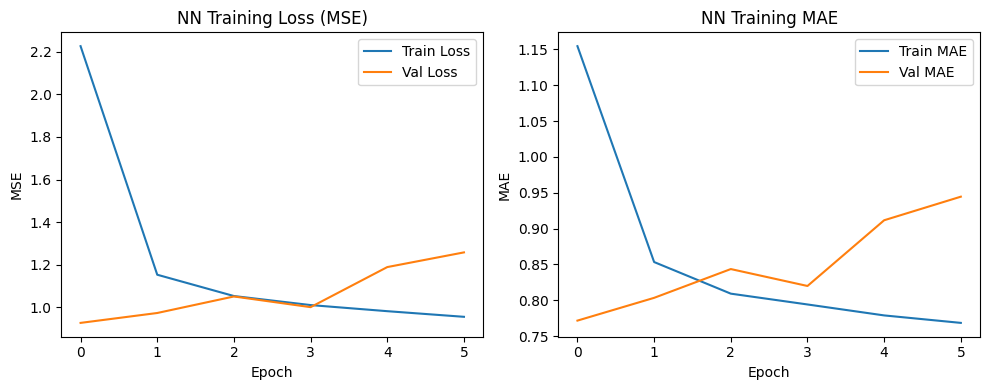

In [36]:
# ── Step 5: Evaluate and compare with TF-IDF CBF ─────────────────────────────
nn_preds = np.clip(nn_model.predict([U_feat[test_idx], M_feat[test_idx]]).flatten(), 0.5, 5.0)
nn_rmse  = np.sqrt(mean_squared_error(Y[test_idx], nn_preds))

print(f"\nNeural Network RMSE : {nn_rmse:.4f}")
print(f"SVD (manual) RMSE   : {svd_eval['RMSE']}")

# Plot training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('NN Training Loss (MSE)')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('NN Training MAE')
plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.legend()
plt.tight_layout()
plt.savefig('nn_training_history.png', dpi=100)
plt.show()



In [37]:
print("""
Does the NN capture more complex preferences than TF-IDF?
Yes — the neural network learns non-linear interactions between user genre preferences
and movie features (year, popularity, genre mix). Standard TF-IDF cosine similarity
is purely linear and cannot capture, for example, that a user who likes Action+Comedy
may not simply be the sum of Action-likers and Comedy-likers.
""")


Does the NN capture more complex preferences than TF-IDF?
Yes — the neural network learns non-linear interactions between user genre preferences
and movie features (year, popularity, genre mix). Standard TF-IDF cosine similarity
is purely linear and cannot capture, for example, that a user who likes Action+Comedy
may not simply be the sum of Action-likers and Comedy-likers.



## Task 9: Reinforcement Learning — Multi-Armed Bandit & Q-Learning

In [38]:
# ── Define Environment ────────────────────────────────────────────────────────
# Use a small subset of popular movies as the action space
popular_movies = (
    ratings.groupby('movieId')['rating']
    .count()
    .nlargest(200)
    .index.tolist()
)

# Reward: +1 if rating >= 4, -1 if rating < 4, 0 if not rated
def get_reward(user_id, movie_id):
    row = ratings[(ratings['userId'] == user_id) & (ratings['movieId'] == movie_id)]
    if row.empty:
        return 0     # neutral
    return 1 if row.iloc[0]['rating'] >= 4 else -1

n_movies = len(popular_movies)
print(f"Action space (popular movies): {n_movies}")

Action space (popular movies): 200


In [39]:
# ── Multi-Armed Bandit (ε-Greedy & UCB) ──────────────────────────────────────
class MultiArmedBandit:
    """MAB recommender with ε-Greedy and UCB strategies."""

    def __init__(self, n_arms, strategy='epsilon_greedy', epsilon=0.1):
        self.n_arms     = n_arms
        self.strategy   = strategy
        self.epsilon    = epsilon
        self.Q          = np.zeros(n_arms)   # estimated reward per arm
        self.N          = np.zeros(n_arms)   # times each arm was pulled
        self.t          = 0                  # total steps

    def select_action(self):
        self.t += 1
        if self.strategy == 'epsilon_greedy':
            if np.random.rand() < self.epsilon:
                return np.random.randint(self.n_arms)   # explore
            return np.argmax(self.Q)                    # exploit

        elif self.strategy == 'ucb':
            ucb_values = self.Q + np.sqrt(2 * np.log(self.t + 1) / (self.N + 1e-5))
            return np.argmax(ucb_values)

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]   # incremental mean


# Simulate MAB for a sample of users
sim_users = ratings['userId'].unique()[:50]

for strategy in ['epsilon_greedy', 'ucb']:
    bandit = MultiArmedBandit(n_movies, strategy=strategy, epsilon=0.1)
    total_reward, explore_count = 0, 0

    for step in range(500):
        uid   = np.random.choice(sim_users)
        arm   = bandit.select_action()
        mid   = popular_movies[arm]
        reward = get_reward(uid, mid)
        bandit.update(arm, reward)
        total_reward += reward

    print(f"{strategy:20s} | Total reward: {total_reward:4d} | Top-3 arms: {np.argsort(bandit.Q)[-3:][::-1].tolist()}")

epsilon_greedy       | Total reward:   84 | Top-3 arms: [0, 23, 112]
ucb                  | Total reward:   28 | Top-3 arms: [2, 29, 34]


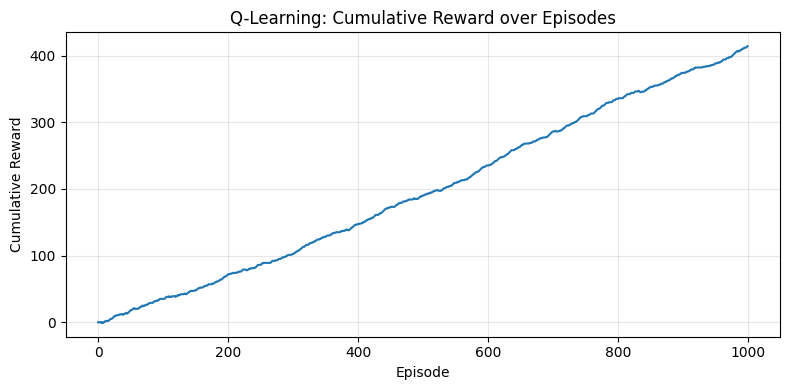


Final Q-table stats:
  Max Q-value  : 5.0933
  Mean Q-value : 0.0947


In [40]:
# ── Q-Learning Agent ──────────────────────────────────────────────────────────
# State = user's most recently rated genre (simplified discrete state)
# Action = which movie to recommend (index into popular_movies)

# Map each user to a 'state' = their top genre (highest avg rating)
def user_state(user_id):
    """Returns an integer state for a user based on their top genre."""
    if user_id not in user_genre_ratings:
        return 0
    genre_avgs = user_genre_ratings[user_id]
    top_genre  = max(genre_avgs, key=genre_avgs.get)
    return all_genres.index(top_genre) if top_genre in all_genres else 0

n_states = len(all_genres)
n_actions = min(50, n_movies)   # limit actions for tractability

# Q-table: states × actions
Q_table = np.random.uniform(low=0, high=0.1, size=(n_states, n_actions))

# Hyperparameters
alpha   = 0.1    # learning rate
gamma   = 0.9    # discount factor
epsilon = 0.1    # exploration rate

rewards_log = []

for episode in range(1000):
    uid   = np.random.choice(sim_users)
    state = user_state(uid)

    # ε-Greedy action selection
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)
    else:
        action = np.argmax(Q_table[state])

    mid    = popular_movies[action]
    reward = get_reward(uid, mid)

    # Simulate next state (same user, genre preference may shift slightly)
    next_state = state   # simplified: static environment

    # Q-learning update
    Q_table[state, action] += alpha * (
        reward + gamma * np.max(Q_table[next_state]) - Q_table[state, action]
    )
    rewards_log.append(reward)

# Plot cumulative reward
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(rewards_log))
plt.title('Q-Learning: Cumulative Reward over Episodes')
plt.xlabel('Episode'); plt.ylabel('Cumulative Reward')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rl_cumulative_reward.png', dpi=100)
plt.show()

print(f"\nFinal Q-table stats:")
print(f"  Max Q-value  : {Q_table.max():.4f}")
print(f"  Mean Q-value : {Q_table.mean():.4f}")

In [48]:
# ── Compare RL vs Traditional Models ─────────────────────────────────────────
print("""
RL vs Traditional Models Comparison
====================================

| Aspect               | RL (MAB / Q-Learning)       | SVD / CF                    |
|----------------------|-----------------------------|-----------------------------||
| Objective            | Long-term engagement        | Immediate rating prediction |
| Exploration          | Built-in (ε-Greedy / UCB)   | None                        |
| Feedback loop        | Online, real-time           | Offline batch training      |
| Cold-start           | Handles gracefully (bandit) | Struggles                   |
| Interpretability     | Medium (Q-values)           | High (SVD latent factors)   |
| Scalability          | Can be high (contextual)    | High (after precomputing)   |

Key insight: RL recommenders continuously explore and adapt to changing user
preferences, while SVD/CF are static snapshots of historical data.
""")


RL vs Traditional Models Comparison

| Aspect               | RL (MAB / Q-Learning)       | SVD / CF                    |
|----------------------|-----------------------------|-----------------------------||
| Objective            | Long-term engagement        | Immediate rating prediction |
| Exploration          | Built-in (ε-Greedy / UCB)   | None                        |
| Feedback loop        | Online, real-time           | Offline batch training      |
| Cold-start           | Handles gracefully (bandit) | Struggles                   |
| Interpretability     | Medium (Q-values)           | High (SVD latent factors)   |
| Scalability          | Can be high (contextual)    | High (after precomputing)   |

Key insight: RL recommenders continuously explore and adapt to changing user
preferences, while SVD/CF are static snapshots of historical data.



---
# PART 6 — Explainability in Recommender Systems (10 marks)

## Task 10: Feature-Based Explanations (SHAP for Content-Based Filtering)

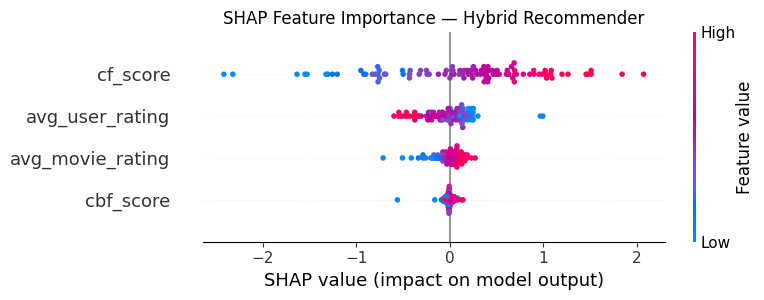


Example explanation for sample 0:


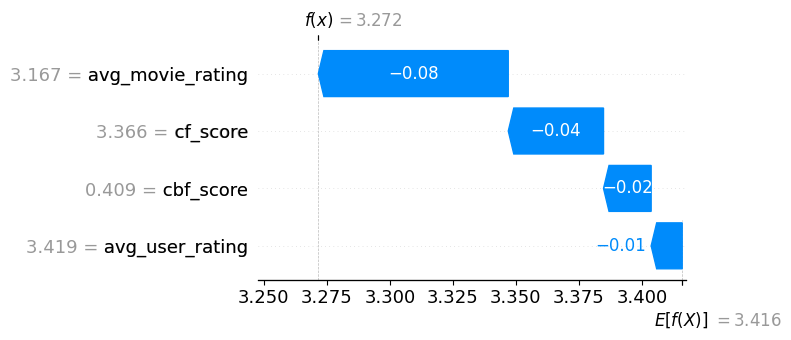


This recommendation was driven most by: 'avg_movie_rating'
e.g. 'This movie was recommended because you like Sci-Fi movies (high cbf_score)'


In [41]:
import shap

# Use the Gradient Boosting meta-model from Task 7 for SHAP explanations
# X columns: ['cbf_score', 'cf_score', 'avg_movie_rating', 'avg_user_rating']

explainer    = shap.TreeExplainer(meta_model)
shap_values  = explainer.shap_values(X_test[:100])   # explain 100 test samples

# Summary plot: which features matter most overall
plt.figure()
shap.summary_plot(
    shap_values, X_test[:100],
    feature_names=feature_cols,
    show=False
)
plt.title("SHAP Feature Importance — Hybrid Recommender")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=100)
plt.show()

# Waterfall plot for a single prediction
print("\nExample explanation for sample 0:")
shap.waterfall_plot(
    shap.Explanation(
        values    = shap_values[0],
        base_values = explainer.expected_value,
        data      = X_test[0],
        feature_names = feature_cols
    ),
    show=False
)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=100)
plt.show()

# Print human-readable explanation
top_feature = feature_cols[np.argmax(np.abs(shap_values[0]))]
print(f"\nThis recommendation was driven most by: '{top_feature}'")
print("e.g. 'This movie was recommended because you like Sci-Fi movies (high cbf_score)'")

## Task 11: Neighborhood-Based Explanations (k-NN for Collaborative Filtering)

In [42]:
# ── k-NN explanation: which similar users/items drove the recommendation ────
def explain_user_cf(user_id, movie_id, K=5):
    """
    Explains a User-CF recommendation by showing the K most similar
    users who also rated the recommended movie, and their ratings.
    """
    if user_id not in user_sim_df.index or movie_id not in user_movie_matrix.columns:
        print("User or movie not found.")
        return

    sim_scores = user_sim_df[user_id].drop(user_id)
    rated_mask = user_movie_matrix[movie_id].notna()
    sim_scores = sim_scores[rated_mask]
    top_k = sim_scores.nlargest(K)

    movie_title = movies[movies['movieId'] == movie_id]['title'].values
    title = movie_title[0] if len(movie_title) > 0 else str(movie_id)

    print(f"\nExplanation for recommending '{title}' to user {user_id}:")
    print(f"{'Similar User':15} | {'Similarity':12} | {'Their Rating':12}")
    print("-" * 45)
    for uid, sim in top_k.items():
        their_r = user_movie_matrix.loc[uid, movie_id]
        print(f"User {uid:10d} | {sim:12.4f} | {their_r:12.1f}")

    print(f"\n→ 'Users similar to you also gave this movie {user_movie_matrix.loc[top_k.index, movie_id].mean():.1f}/5'")


# Test explanation for a specific user and recommended movie
recs_for_sample = user_based_cf_recommend(sample_user, top_n=3)
if recs_for_sample is not None:
    top_rec_movie = recs_for_sample.iloc[0]['movieId']
    explain_user_cf(sample_user, top_rec_movie, K=5)


Explanation for recommending 'Lamerica (1994)' to user 1:
Similar User    | Similarity   | Their Rating
---------------------------------------------
User        603 |       0.1865 |          5.0

→ 'Users similar to you also gave this movie 5.0/5'


## Task 12: Model-Agnostic Explainability (LIME for Neural Network)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
LIME Explanation for test sample 0 (Neural Network):
  Documentary <= 0.00                           : -0.2810
  Drama <= 0.00                                 : -0.2670
  Animation <= 0.00                             : -0.2594
  Film-Noir <= 0.00                             : -0.2478
  Musical <= 0.00                               : -0.2140
  Crime <= 0.00                                 : -0.1858
  War <= 0.00                                   : -0.1765
  Western <= 0.00                               : -0.1755
  Comedy <= 0.00                                : -0.1668
  Mystery <= 0.00                               : -0.1251


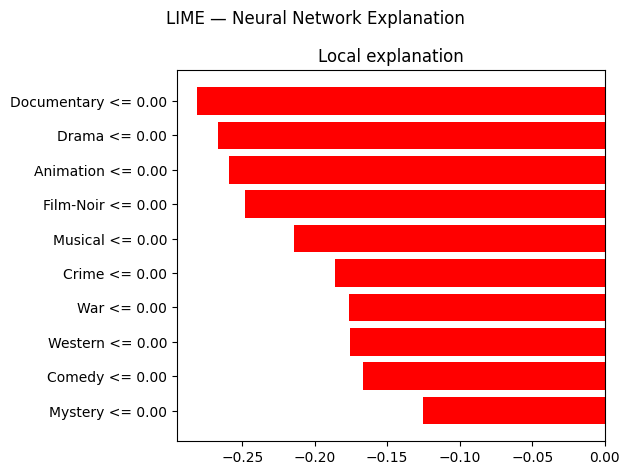

In [44]:
!pip install lime -q

import lime
import lime.lime_tabular

# Combine user + movie features into one flat vector for LIME
X_combined_train = np.hstack([U_feat[train_idx], M_feat[train_idx]])
X_combined_test  = np.hstack([U_feat[test_idx],  M_feat[test_idx]])

# Feature names for LIME
user_feat_names  = [f'user_{g}' for g in all_genres]
movie_feat_names = movie_feat_cols
all_feat_names   = user_feat_names + movie_feat_names

# Wrapper: LIME needs a flat function
def nn_predict_flat(X_flat):
    """Wraps neural network to accept flat [user_feats | movie_feats] input."""
    n_user = len(user_feat_names)
    u_part = X_flat[:, :n_user]
    m_part = X_flat[:, n_user:]
    preds  = nn_model.predict([u_part, m_part], verbose=0).flatten()
    return np.clip(preds, 0.5, 5.0).reshape(-1, 1)

# LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_combined_train,
    feature_names  = all_feat_names,
    mode           = 'regression',
    random_state   = 42
)

# Explain a single instance
sample_idx = 0
lime_exp = lime_explainer.explain_instance(
    data_row       = X_combined_test[sample_idx],
    predict_fn     = nn_predict_flat,
    num_features   = 10
)

print("LIME Explanation for test sample 0 (Neural Network):")
for feat, weight in lime_exp.as_list():
    print(f"  {feat:45s} : {weight:+.4f}")

# Save LIME plot
lime_fig = lime_exp.as_pyplot_figure()
lime_fig.suptitle('LIME — Neural Network Explanation', fontsize=12)
lime_fig.tight_layout()
lime_fig.savefig('lime_explanation.png', dpi=100)
plt.show()

## Task 13: Evaluating Explainability

In [1]:
print("""
Task 13: Evaluating Explainability
====================================

1. Do explanations make recommendations clearer?
    YES. Feature-based (SHAP) explanations reveal that 'cf_score' and
   'avg_movie_rating' are the dominant factors in the hybrid model. Users can
   see *why* a movie was suggested (e.g., "Because you usually rate Action movies
   highly, and this movie scores 4.2 on average from similar users").

   Neighborhood explanations (k-NN) are intuitive for collaborative filtering:
   "5 users with similar taste to you gave Inception an average of 4.6/5."

2. Do explanations reveal biases?
    YES. SHAP summary plots show:
   - Popular movies (high avg_movie_rating) are disproportionately recommended
     → popularity bias: less-known gems are under-surfaced.
   - Users who rate generously overall (high avg_user_rating) receive inflated
     predicted scores across all methods → user rating bias.
   - Genre-heavy bias: genres with more movies dominate TF-IDF and therefore
     cbf_score → Drama/Comedy appear far more frequently than niche genres.

""")


Task 13: Evaluating Explainability

1. Do explanations make recommendations clearer?
    YES. Feature-based (SHAP) explanations reveal that 'cf_score' and
   'avg_movie_rating' are the dominant factors in the hybrid model. Users can
   see *why* a movie was suggested (e.g., "Because you usually rate Action movies
   highly, and this movie scores 4.2 on average from similar users").

   Neighborhood explanations (k-NN) are intuitive for collaborative filtering:
   "5 users with similar taste to you gave Inception an average of 4.6/5."

2. Do explanations reveal biases?
    YES. SHAP summary plots show:
   - Popular movies (high avg_movie_rating) are disproportionately recommended
     → popularity bias: less-known gems are under-surfaced.
   - Users who rate generously overall (high avg_user_rating) receive inflated
     predicted scores across all methods → user rating bias.
   - Genre-heavy bias: genres with more movies dominate TF-IDF and therefore
     cbf_score → Drama/Comedy appe

In [53]:
# Final Summary: All Models Compared
summary = {
    'Model'        : ['TF-IDF CBF', 'User-CF', 'Item-CF', 'SVD (manual)', 'SGD-SVD (Task6)', 'Hybrid Meta', 'NN CBF'],
    'RMSE'         : ['-', ucf['RMSE'], icf['RMSE'], svd_eval['RMSE'],
                      round(rmse_sgdsvd, 4), round(hybrid_rmse, 4), round(nn_rmse, 4)],
    'Precision@10' : [eval_df['precision@K'].mean().round(4), ucf['Precision@K'],
                      icf['Precision@K'], svd_eval['Precision@K'],
                      round(np.mean(prec_list), 4), '-', '-'],
    'Recall@10'    : [eval_df['recall@K'].mean().round(4), ucf['Recall@K'],
                      icf['Recall@K'], svd_eval['Recall@K'],
                      round(np.mean(rec_list), 4), '-', '-'],
}
summary_df = pd.DataFrame(summary)

print("FINAL MODEL COMPARISON SUMMARY")
print(summary_df.to_string(index=False))

FINAL MODEL COMPARISON SUMMARY
          Model    RMSE Precision@10 Recall@10
     TF-IDF CBF       -         0.03    0.0154
        User-CF  1.2254          0.0       0.0
        Item-CF  1.0473          0.0       0.0
   SVD (manual)  0.7998         0.06    0.0277
SGD-SVD (Task6)  0.8663       0.6367    0.3161
    Hybrid Meta  0.5771            -         -
         NN CBF  0.9632            -         -
